In [1]:
!pip install scipy

# Problem 1: EDA

**Questions**
- What are the age and gender preferences for movies of different genres? (age, gender, genre)
- Does budget impact the movie's success? (budget, ratings, gross income)
- Does popularity of genres change over time? (year, genre)
- Does genre affect the movie's popularity? (genre, ratings, gross income)
- Are there seasonal differences between genres? (date published, genre)

## Imports and Load Data

In [2]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from scipy import stats
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

metadata = pd.read_csv("IMDb movies.csv")
ratings = pd.read_csv("IMDb ratings.csv")

df = pd.concat([metadata, ratings], axis=1)
# df.head(5)

/var/folders/2b/gxmh627x4vvgpqmv_3dzvbq80000gn/T/ipykernel_77227/1917092231.py:8: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv("IMDb movies.csv")


## Cleaning and Filtering Dataset

In [3]:
# year, date published, budget, usa gross income, worlwide gross income (strings instead of numeric <- need to convert categories later)
# df.info()

### Understand Data for Better Filtering

In [4]:
# no unreasonable vals
# df.describe()

### Dtype Conversions

**Considered categorical features to cast into numeric:**
year, date published, budget, usa gross income, worlwide gross income

In [5]:
# index causing int casting issue for column year 
df.loc[pd.to_numeric(df['year'], errors='coerce').isna(), 'year']

83917    TV Movie 2019
Name: year, dtype: object

In [6]:
# replace index with valid int and convert column year into numeric
df['year'] = df['year'].replace("TV Movie 2019", "2019")
print(df.loc[83917, 'year'])
df['year'] = pd.to_numeric(df['year'])

2019


In [7]:
# convert currency objects into numerics by removing $
# find casting issue for currency objects
# df.loc[pd.to_numeric(df['worlwide_gross_income'], errors='coerce').isna(), 'worlwide_gross_income']
# remove $ through regex
df['worlwide_gross_income'] = df['worlwide_gross_income'].str.replace(r'\D', '', regex=True)
df['budget'] = df['budget'].str.replace(r'\D', '', regex=True)
df['usa_gross_income'] = df['usa_gross_income'].str.replace(r'\D', '', regex=True)
# convert into numeric values
df['worlwide_gross_income'] = pd.to_numeric(df['worlwide_gross_income'])
df['budget'] = pd.to_numeric(df['budget'])
df['usa_gross_income'] = pd.to_numeric(df['usa_gross_income'])

In [8]:
# casting issue: only contains year (4563 samples)
# df.loc[pd.to_datetime(df['date_published'], errors='coerce').isna(), 'date_published'] 
# convert published date object into datetime
df['date_published'] = pd.to_datetime(df['date_published'], errors='coerce')

In [9]:
# check for proper conversion
# print(df['worlwide_gross_income'])
# print(df['budget'])
# print(df['usa_gross_income'])
# print(df['date_published'])

### Removing Duplicates

In [10]:
# include all unique columns (exclude all rows of duplicates)
mask = df.columns.duplicated()
# print(df.columns[mask])
df = df.loc[:, ~(mask)]
# print(df.columns.duplicated().any())
# df.isna().sum()

## Genre & Gender

**Create a unique list of genres**
- order by frequency
- create list of top 6 most relevant genres

In [11]:
genres = df['genre'].str.split(',')

In [12]:
genres = genres.explode().str.strip()

In [13]:
genre_count = genres.value_counts()

In [14]:
genre_6 = genre_count.head(6).index.tolist()

In [15]:
genres = genres.unique()

In [16]:
# print(genres)
# print(genre_count)
# print(genre_6)

In [17]:
# create new boolean columns of each unique genre to represent the presence of each per movie
for g in genres:
    df[f'is{g}'] = df['genre'].str.contains(g).astype(int)

In [18]:
# increase sample threshold to reduce noise
votes = df[(df['males_allages_votes'] >= 100) & (df['females_allages_votes'] >= 100)].copy()
# print(votes.shape)

gender_genre = []

for g in genre_6:
    # filter movies in reduced sample for current genre
    genre_movies = votes[votes[f'is{g}'] == 1]
    if len(genre_movies) > 0:
        male_avg = genre_movies['males_allages_avg_vote'].mean()
        female_avg = genre_movies['females_allages_avg_vote'].mean()

        gender_genre.append({'genre': g, 'male_avg': male_avg, 'female_avg': female_avg})

gender_genre_df = pd.DataFrame(gender_genre)
        

**Dumbell Plot**
- 2 values (M/F) per genre
- show difference between the values
- genres are independent

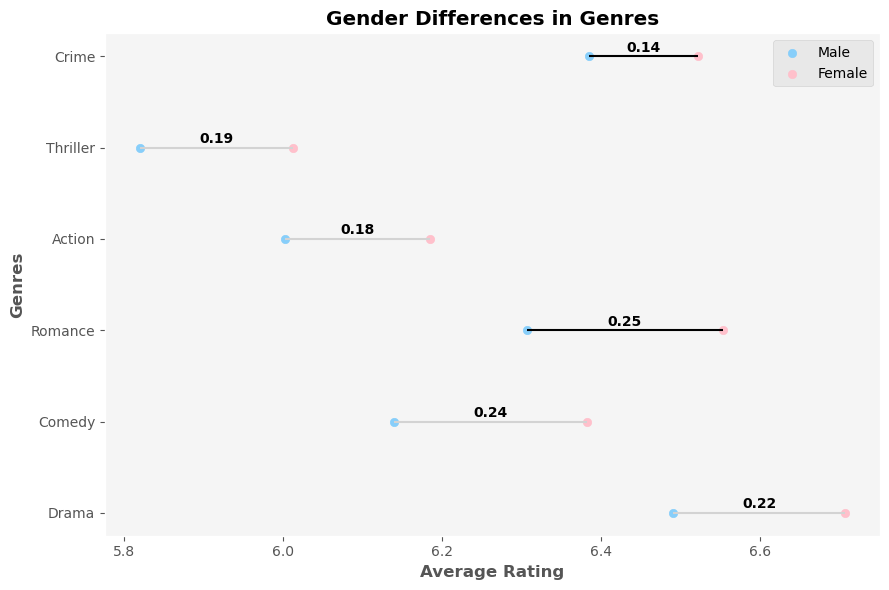

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))

genre_yval = range(len(gender_genre_df))

color_filter = ['black' if g == 'Crime' or g== 'Romance' else 'lightgray' for g in gender_genre_df['genre']]

ax.hlines(y=genre_yval, xmin=gender_genre_df['female_avg'], xmax=gender_genre_df['male_avg'], color=color_filter)
ax.scatter(gender_genre_df['male_avg'], genre_yval, color='lightskyblue', label='Male')
ax.scatter(gender_genre_df['female_avg'], genre_yval, color='pink', label='Female')

for i in range(len(gender_genre_df)):
    f_avg = gender_genre_df['female_avg'][i]
    m_avg = gender_genre_df['male_avg'][i]
    diff = f_avg - m_avg
    ax.text((f_avg + m_avg)/2, i+0.05, f'{diff:.2f}', ha='center', fontweight='bold')

ax.set_yticks(genre_yval)
ax.set_yticklabels(gender_genre_df['genre'])
ax.set_ylabel('Genres', fontweight='bold')
ax.set_xlabel('Average Rating', fontweight='bold')
ax.set_title('Gender Differences in Genres', fontweight='bold')
ax.grid(False)
ax.set_facecolor('whitesmoke')
plt.legend()
plt.tight_layout()
plt.show()


## Age and Genre

In [20]:
age_groups = ['0age', '18age', '30age', '45age']
age_labels = ['<18', '18-29', '30-45', '45+']
age_genre = []

for g in genre_6:
    genre_movies = votes[votes[f'is{g}'] == 1]

    for group, label in zip(age_groups, age_labels):
        movies = genre_movies[genre_movies[f'allgenders_{group}_votes'] >= 10]

        if len(movies) > 0:
            avg_rating = movies[f'allgenders_{group}_avg_vote'].mean()

            age_genre.append({'avg_rating': avg_rating, 'age_group': label, 'genre': g})

age_genre_df = pd.DataFrame(age_genre)

**Heat Map**
- comparing 2 categories (genre and age group)

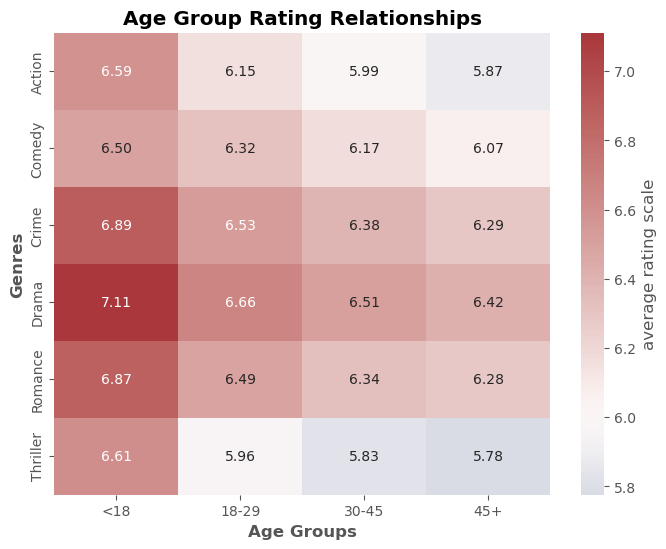

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

data = age_genre_df.pivot(index='genre', columns='age_group', values='avg_rating')
data = data[['<18', '18-29', '30-45', '45+']]

sns.heatmap(data, annot=True, fmt='.2f', cmap='vlag', center=6, cbar_kws={'label': 'average rating scale'})
ax.set_ylabel('Genres', fontweight='bold')
ax.set_xlabel('Age Groups', fontweight='bold')
ax.set_title("Age Group Rating Relationships", fontweight='bold')
plt.show()

## Genre by Time 

In [22]:
# find range of year column
# mins (1894, 1906)
# maxs (2020)
# sorted(df['year'].unique())

In [23]:
# df.loc[df['year'] == 1894, 'imdb_title_id']
# df = df.drop(:df.loc[df['year']==1894]

In [24]:
# movie count per year (denom)
freq_yr = df.groupby('year').size().rename('count')

genre_yr = []

for g in genre_6:
    # movies in curr genre for all yrs counter
    counter = df.groupby('year')[f'is{g}'].sum()

    temp = pd.DataFrame({'year': counter.index, 'genre': g, 'percent': (counter/freq_yr*100.0).values})
    genre_yr.append(temp)

genre_yr_df = pd.concat(genre_yr)
# genre_yr_df.head()

Drama:
p val: 2.0092925143369263e-12
r val: -0.6028949448901332
Comedy:
p val: 9.000912655078216e-11
r val: 0.5645341448252076
Romance:
p val: 4.781955685953757e-11
r val: -0.5712711276214393
Action:
p val: 1.1211679807548357e-32
r val: 0.8518881536437992
Thriller:
p val: 8.293337616124515e-79
r val: 0.9798671255236736
Crime:
p val: 0.00047192106744918294
r val: -0.3249914964187639


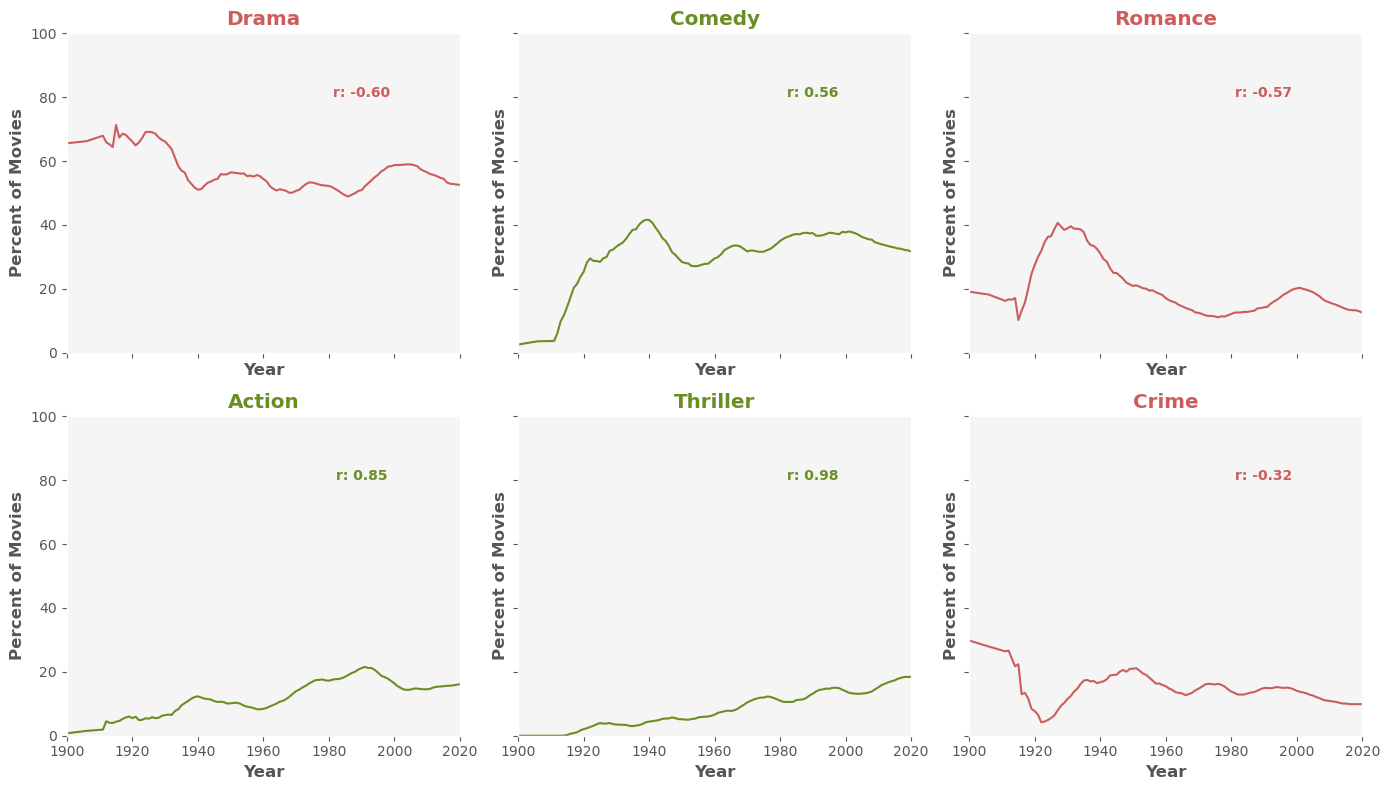

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, g in enumerate(genre_6):
    ax = axes[i]
    ax.set_xlim(1900, 2020)
    ax.set_ylim(0, 100)

    gyd = genre_yr_df[genre_yr_df['genre'] == g].sort_values('year')
    smooth = gyd['percent'].rolling(window=10, min_periods=5, center=True).mean()


    slope, intercept, rvalue, pvalue, stderr = stats.linregress(gyd['year'], smooth)
    color = 'olivedrab' if slope > 0 else 'indianred'
  
    ax.set_title(f'{g}', color=color, fontweight='bold')
    ax.set_xlabel('Year', fontweight='bold')
    ax.set_ylabel('Percent of Movies', fontweight='bold')
    ax.grid(False)
    ax.set_facecolor('whitesmoke')
    ax.plot(gyd['year'], smooth, color=color)
    print(f'{g}:')
    print(f'p val: {pvalue}')
    print(f'r val: {rvalue}')

    ax.text(1990, 80, f'r: {rvalue:.2f}', ha='center', color=color, fontweight='bold')
    
plt.tight_layout()
plt.show()

## Budget and Ratings

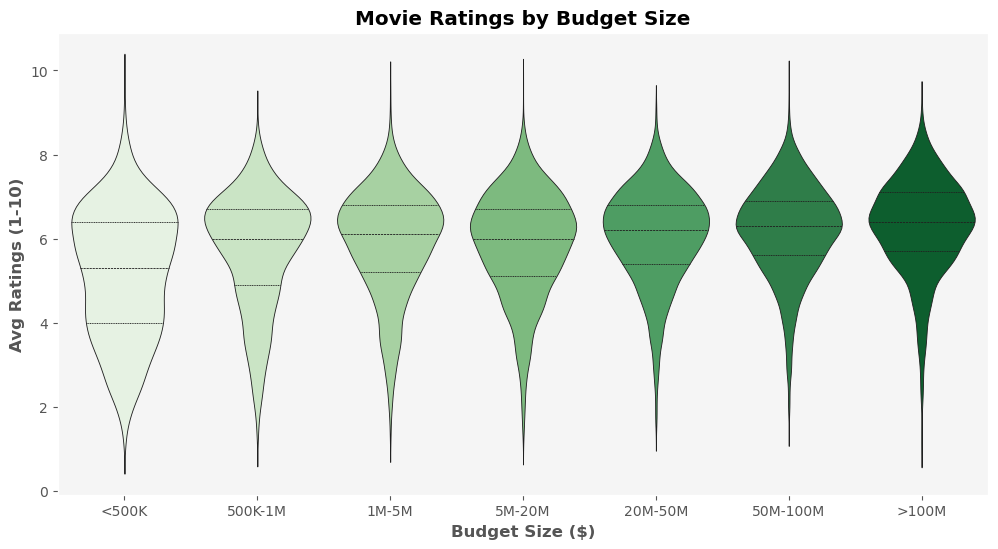

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

rating_df = df[(df['budget'].notna())& (df['budget']>0) & (df['avg_vote'].notna())].copy()
rating_df['budget_categories'] = pd.qcut(rating_df['budget'], q=7, 
                                labels=['<500K', '500K-1M', '1M-5M', '5M-20M', '20M-50M', '50M-100M', '>100M'])


sns.violinplot(data=rating_df, x='budget_categories', y='avg_vote', hue='budget_categories', palette='Greens', inner='quartile', ax=ax, legend=False)
ax.set_xlabel('Budget Size ($)', fontweight='bold')
ax.set_ylabel('Avg Ratings (1-10)', fontweight='bold')
ax.set_title('Movie Ratings by Budget Size', fontweight='bold')
ax.grid(False)
ax.set_facecolor('whitesmoke')
plt.show()

## Season by Genre

In [27]:
def season(month):
    match month:
        case 1|2|12:
            return 'winter'
        case 3|4|5:
            return 'spring'
        case 6|7|8:
            return 'summer'
        case 9|10|11:
            return 'fall'
        case _:
            return None
            
df['month'] = df['date_published'].dt.month
df['season'] = df['month'].apply(season)

season_df = df[df['season'].notna()].copy()
season_genre = []
seasons = ['winter', 'spring', 'summer', 'fall']

for s in seasons:
    movies = season_df[season_df['season']==s]
    denom = len(movies)
    for g in genre_6:
        count = movies[f'is{g}'].sum()

        season_genre.append({'percent': count/denom*100.0, 'genre': g, 'season':s})

season_genre_df= pd.DataFrame(season_genre)

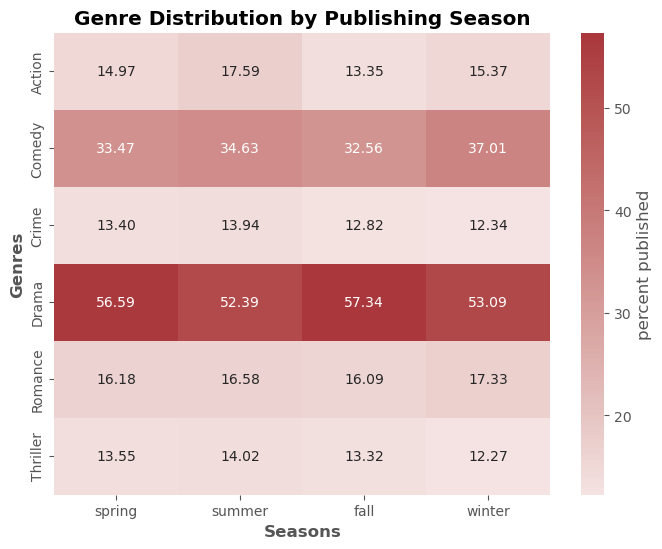

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

season = season_genre_df.pivot(index='genre', columns='season', values='percent')
season = season[['spring', 'summer', 'fall', 'winter']]

sns.heatmap(season, annot=True, fmt='.2f', cmap='vlag', center=6, cbar_kws={'label': 'percent published'})
ax.set_xlabel('Seasons', fontweight='bold')
ax.set_ylabel('Genres', fontweight='bold')
ax.set_title("Genre Distribution by Publishing Season", fontweight='bold')
plt.show()